# Telecom X — Análisis de Evasión de Clientes (Churn)
> **Objetivo:** Extraer, transformar y analizar datos de clientes para identificar los factores que generan cancelaciones, apoyando al equipo de Data Science en la construcción de modelos predictivos.

**Flujo de trabajo:** Extracción → Transformación (ETL) → Análisis Exploratorio (EDA) → Informe Final

# 1. Extracción
Cargamos los datos desde la API de Telecom X (archivo JSON). Utilizamos `requests` para simular el consumo de la API y `pandas` para estructurar los datos.

In [1]:
# ── Instalación y carga de librerías ──
import json
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Configuración visual
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
pd.set_option('display.max_columns', 30)

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [2]:
# ── Extracción desde la API ──
URL_API = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

response = requests.get(URL_API)
response.raise_for_status()  # Lanza error si la petición falla

raw_data = response.json()
print(f'Datos extraídos correctamente')
print(f'   → Tipo de respuesta : {type(raw_data)}')
print(f'   → Total de registros: {len(raw_data):,}')
print(f'\n Estructura del primer registro:')
print(json.dumps(raw_data[0], indent=2))

Datos extraídos correctamente
   → Tipo de respuesta : <class 'list'>
   → Total de registros: 7,267

 Estructura del primer registro:
{
  "customerID": "0002-ORFBO",
  "Churn": "No",
  "customer": {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "Yes",
    "tenure": 9
  },
  "phone": {
    "PhoneService": "Yes",
    "MultipleLines": "No"
  },
  "internet": {
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "Yes",
    "StreamingTV": "Yes",
    "StreamingMovies": "No"
  },
  "account": {
    "Contract": "One year",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Mailed check",
    "Charges": {
      "Monthly": 65.6,
      "Total": "593.3"
    }
  }
}


In [3]:
# ── Normalización del JSON anidado a DataFrame plano ──
df_raw = pd.json_normalize(raw_data)

print(f'Shape inicial: {df_raw.shape}')
print(f'\nColumnas generadas:')
for col in df_raw.columns:
    print(f'  {col}')
df_raw.head(3)

Shape inicial: (7267, 21)

Columnas generadas:
  customerID
  Churn
  customer.gender
  customer.SeniorCitizen
  customer.Partner
  customer.Dependents
  customer.tenure
  phone.PhoneService
  phone.MultipleLines
  internet.InternetService
  internet.OnlineSecurity
  internet.OnlineBackup
  internet.DeviceProtection
  internet.TechSupport
  internet.StreamingTV
  internet.StreamingMovies
  account.Contract
  account.PaperlessBilling
  account.PaymentMethod
  account.Charges.Monthly
  account.Charges.Total


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


# 2. Transformación (ETL)
Aplicamos un pipeline de limpieza y enriquecimiento de datos:
1. Renombrado de columnas
2. Corrección de tipos de datos
3. Tratamiento de valores nulos / vacíos
4. Estandarización de variables categóricas
5. Ingeniería de características (feature engineering)

In [4]:
# ── 2.1 Renombrado de columnas ──
df = df_raw.copy()

rename_map = {
    'customerID'                   : 'customer_id',
    'Churn'                        : 'churn',
    'customer.gender'              : 'gender',
    'customer.SeniorCitizen'       : 'senior_citizen',
    'customer.Partner'             : 'partner',
    'customer.Dependents'          : 'dependents',
    'customer.tenure'              : 'tenure',
    'phone.PhoneService'           : 'phone_service',
    'phone.MultipleLines'          : 'multiple_lines',
    'internet.InternetService'     : 'internet_service',
    'internet.OnlineSecurity'      : 'online_security',
    'internet.OnlineBackup'        : 'online_backup',
    'internet.DeviceProtection'    : 'device_protection',
    'internet.TechSupport'         : 'tech_support',
    'internet.StreamingTV'         : 'streaming_tv',
    'internet.StreamingMovies'     : 'streaming_movies',
    'account.Contract'             : 'contract',
    'account.PaperlessBilling'     : 'paperless_billing',
    'account.PaymentMethod'        : 'payment_method',
    'account.Charges.Monthly'      : 'monthly_charges',
    'account.Charges.Total'        : 'total_charges',
}

df.rename(columns=rename_map, inplace=True)
print('Columnas renombradas')
print(df.columns.tolist())

Columnas renombradas
['customer_id', 'churn', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges']


In [5]:
# ── 2.2 Diagnóstico inicial ──
print('=' * 55)
print('RESUMEN DE CALIDAD DE DATOS')
print('=' * 55)
print(f'Registros  : {df.shape[0]:,}')
print(f'Columnas   : {df.shape[1]}')
print()

# Nulos y cadenas vacías
nulos = df.isnull().sum()
vacios = (df == '').sum()
resumen = pd.DataFrame({'nulos': nulos, 'vacios': vacios})
resumen = resumen[resumen.sum(axis=1) > 0]
if resumen.empty:
    print('Sin valores nulos')
else:
    print('Columnas con problemas:')
    print(resumen)

print()
print('Tipos de datos:')
print(df.dtypes)

RESUMEN DE CALIDAD DE DATOS
Registros  : 7,267
Columnas   : 21

Columnas con problemas:
       nulos  vacios
churn      0     224

Tipos de datos:
customer_id           object
churn                 object
gender                object
senior_citizen         int64
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges         object
dtype: object


In [6]:
# ── 2.3 Corrección de tipos de datos ──

# total_charges: convertir string → float (reemplazar vacíos con NaN)
df['total_charges'] = pd.to_numeric(df['total_charges'], errors='coerce')

# churn vacío → tratarlo como NaN
df['churn'] = df['churn'].replace('', np.nan)

print('Registros con churn nulo:', df['churn'].isnull().sum())
print('Registros con total_charges nulo:', df['total_charges'].isnull().sum())

Registros con churn nulo: 224
Registros con total_charges nulo: 11


In [7]:
# ── 2.4 Tratamiento de valores faltantes ──

# Registros sin churn definido → no se pueden usar para análisis supervisado
df_clean = df.dropna(subset=['churn']).copy()
print(f'Registros eliminados (churn vacío): {df.shape[0] - df_clean.shape[0]}')

# total_charges nulo → imputar con mediana (clientes nuevos con tenure=0)
mediana_total = df_clean['total_charges'].median()
df_clean['total_charges'] = df_clean['total_charges'].fillna(mediana_total)

print(f'Registros finales: {df_clean.shape[0]:,}')
print(f'Nulos restantes  : {df_clean.isnull().sum().sum()}')

Registros eliminados (churn vacío): 224
Registros finales: 7,043
Nulos restantes  : 0


In [8]:
# ── 2.5 Estandarización de variables categóricas ──

# Columnas binarias Yes/No → 1/0
binary_cols = [
    'partner', 'dependents', 'phone_service', 'paperless_billing',
    'online_security', 'online_backup', 'device_protection',
    'tech_support', 'streaming_tv', 'streaming_movies'
]

for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0,
                                        'No internet service': 0,
                                        'No phone service': 0})

# Churn → binario
df_clean['churn'] = df_clean['churn'].map({'Yes': 1, 'No': 0}).astype(int)

# Senior citizen ya es 0/1, gender → binario
df_clean['gender'] = df_clean['gender'].map({'Male': 1, 'Female': 0})

print('Variables estandarizadas')
df_clean[binary_cols + ['churn', 'gender']].head(3)

Variables estandarizadas


,partner,dependents,phone_service,paperless_billing,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,churn,gender
0,1,1,1,1,0,1,0,1,1,0,0,0
1,0,0,1,0,0,0,0,0,0,1,0,1
2,0,0,1,1,0,0,1,0,0,0,1,1


In [9]:
# ── 2.6 Feature Engineering ──

# Número total de servicios contratados
service_cols = ['phone_service', 'multiple_lines', 'online_security',
                'online_backup', 'device_protection', 'tech_support',
                'streaming_tv', 'streaming_movies']

# multiple_lines tiene 'No phone service' todavía, estandarizamos
df_clean['multiple_lines'] = df_clean['multiple_lines'].map(
    {'Yes': 1, 'No': 0, 'No phone service': 0})

df_clean['total_services'] = df_clean[service_cols].sum(axis=1)

# Segmento de antigüedad
df_clean['tenure_group'] = pd.cut(
    df_clean['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12m', '13-24m', '25-48m', '49-72m'],
    include_lowest=True
)

# Cargo mensual promedio por servicio
df_clean['charge_per_service'] = (
    df_clean['monthly_charges'] / df_clean['total_services'].replace(0, 1)
).round(2)

print('Nuevas variables creadas:')
print('  → total_services, tenure_group, charge_per_service')
df_clean[['tenure', 'tenure_group', 'total_services',
           'monthly_charges', 'charge_per_service', 'churn']].head(5)

Nuevas variables creadas:
  → total_services, tenure_group, charge_per_service


,tenure,tenure_group,total_services,monthly_charges,charge_per_service,churn
0,9,0-12m,4,65.6,16.40,0
1,9,0-12m,3,59.9,19.97,0
2,4,0-12m,2,73.9,36.95,1
3,13,13-24m,5,98.0,19.60,1
4,3,0-12m,3,83.9,27.97,1


In [10]:
# ── 2.7 Resumen del DataFrame final ──
print(f'Shape final: {df_clean.shape}')
print()
df_clean.info()
print()
df_clean.describe().round(2)

Shape final: (7043, 24)

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   customer_id         7043 non-null   object  
 1   churn               7043 non-null   int64   
 2   gender              7043 non-null   int64   
 3   senior_citizen      7043 non-null   int64   
 4   partner             7043 non-null   int64   
 5   dependents          7043 non-null   int64   
 6   tenure              7043 non-null   int64   
 7   phone_service       7043 non-null   int64   
 8   multiple_lines      7043 non-null   int64   
 9   internet_service    7043 non-null   object  
 10  online_security     7043 non-null   int64   
 11  online_backup       7043 non-null   int64   
 12  device_protection   7043 non-null   int64   
 13  tech_support        7043 non-null   int64   
 14  streaming_tv        7043 non-null   int64   
 15  streaming_movies  

,churn,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,monthly_charges,total_charges,total_services,charge_per_service
count,7043.00,7043.0,7043.00,7043.00,7043.00,7043.00,7043.0,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.27,0.5,0.16,0.48,0.30,32.37,0.9,0.42,0.29,0.34,0.34,0.29,0.38,0.39,0.59,64.76,2281.92,3.36,22.51
std,0.44,0.5,0.37,0.50,0.46,24.56,0.3,0.49,0.45,0.48,0.48,0.45,0.49,0.49,0.49,30.09,2265.27,2.06,11.58
min,0.00,0.0,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.25,18.80,0.00,10.42
25%,0.00,0.0,0.00,0.00,0.00,9.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,35.50,402.22,1.00,15.70
50%,0.00,1.0,0.00,0.00,0.00,29.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,70.35,1397.48,3.00,19.75
75%,1.00,1.0,0.00,1.00,1.00,55.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,89.85,3786.60,5.00,24.52
max,1.00,1.0,1.00,1.00,1.00,72.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,118.75,8684.80,8.00,72.25


# 3. Carga y Análisis Exploratorio (EDA)
Exploramos la distribución de la variable objetivo y los principales factores asociados al churn.

## 3.1 Distribución de la Variable Objetivo — Churn

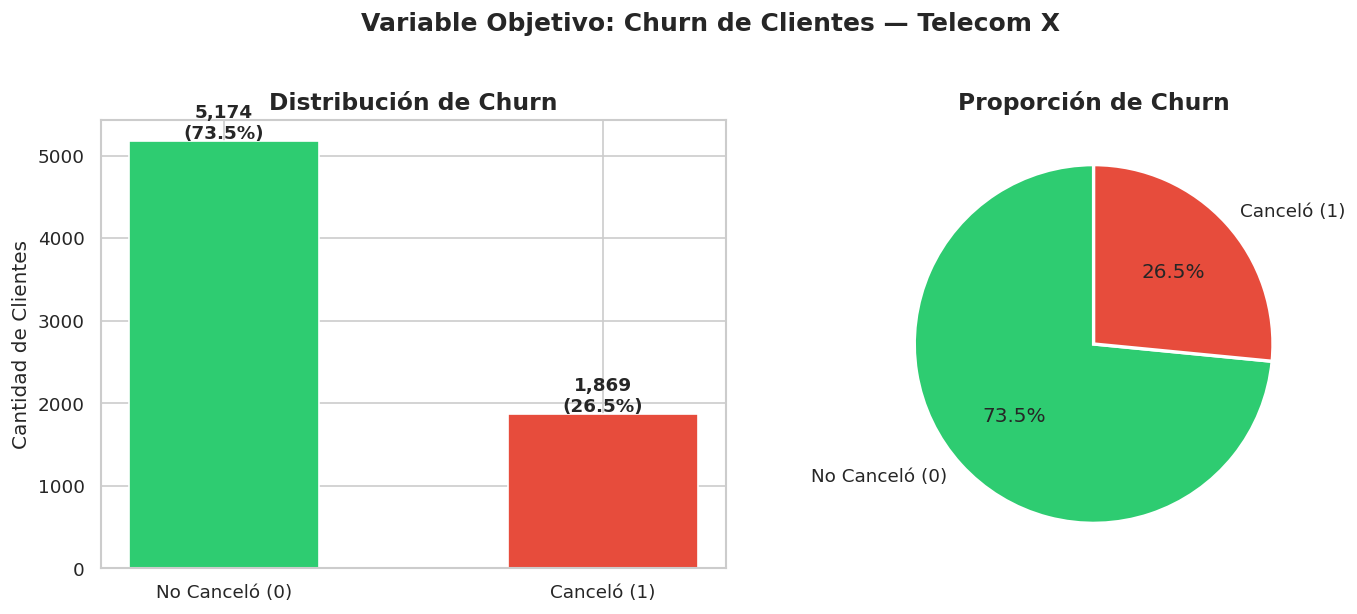

📊 Tasa de churn: 26.54%  |  Clientes que cancelaron: 1,869


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df_clean['churn'].value_counts()
churn_labels = ['No Canceló (0)', 'Canceló (1)']
colors = ['#2ecc71', '#e74c3c']

# Barras
axes[0].bar(churn_labels, churn_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Distribución de Churn', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cantidad de Clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(df_clean)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Pie
axes[1].pie(churn_counts.values, labels=churn_labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Churn', fontsize=14, fontweight='bold')

plt.suptitle('Variable Objetivo: Churn de Clientes — Telecom X',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

tasa = df_clean['churn'].mean() * 100
print(f'📊 Tasa de churn: {tasa:.2f}%  |  Clientes que cancelaron: {churn_counts[1]:,}')

## 3.2 Perfil Demográfico y Churn

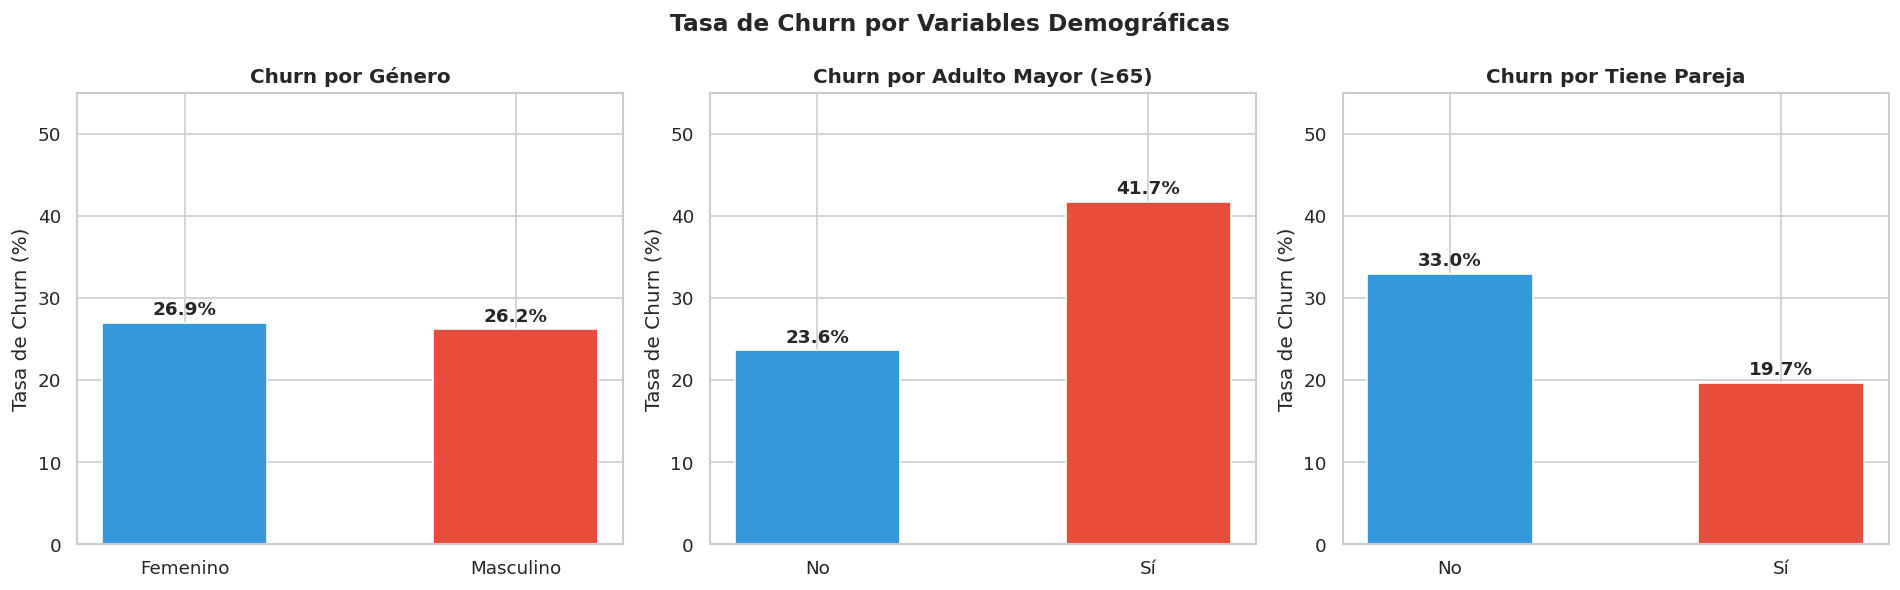

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

demo_vars = {
    'gender'        : ('Género', ['Femenino', 'Masculino']),
    'senior_citizen': ('Adulto Mayor (≥65)', ['No', 'Sí']),
    'partner'       : ('Tiene Pareja', ['No', 'Sí']),
}

for ax, (col, (title, xlabels)) in zip(axes, demo_vars.items()):
    churn_rate = df_clean.groupby(col)['churn'].mean() * 100
    bars = ax.bar(xlabels, churn_rate.values,
                  color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5)
    ax.set_title(f'Churn por {title}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Tasa de Churn (%)')
    ax.set_ylim(0, 55)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Tasa de Churn por Variables Demográficas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.3 Antigüedad del Cliente (Tenure) y Churn

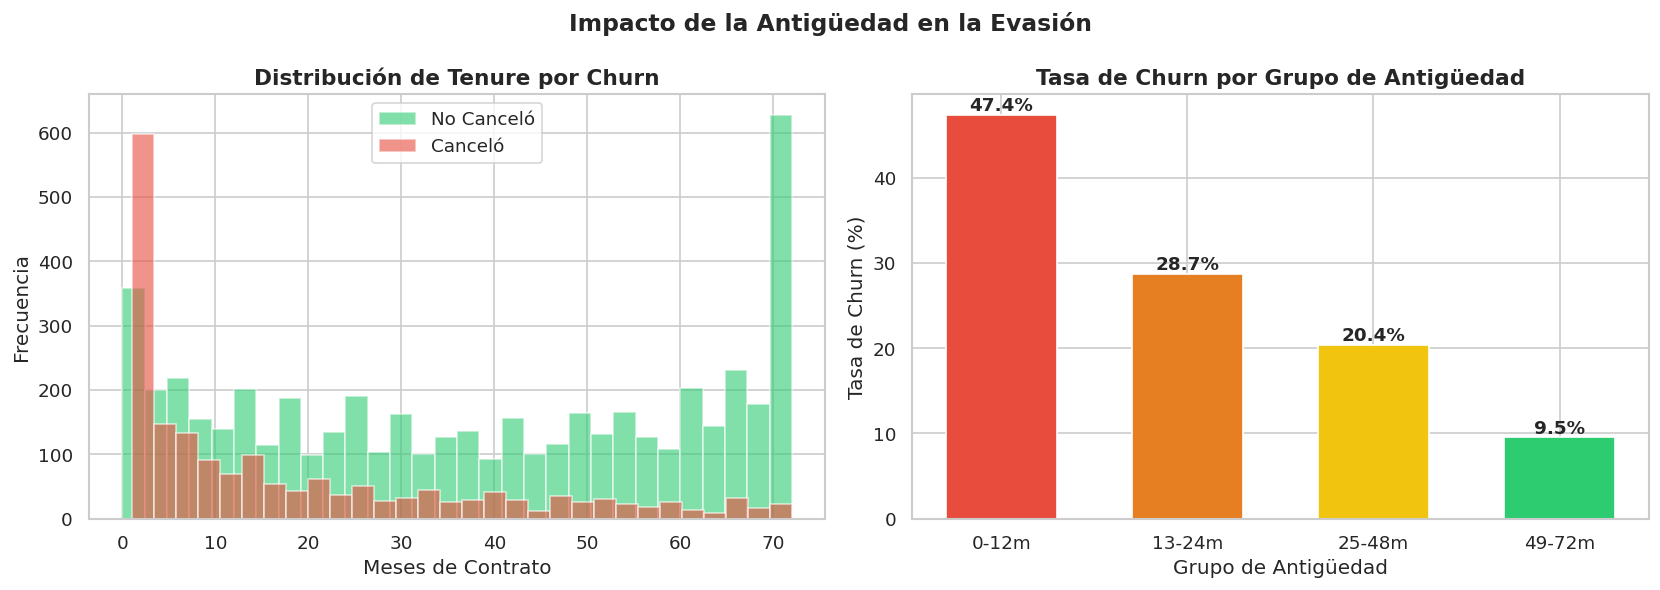

Estadísticas de tenure por churn:
        count   mean    std  min   25%   50%   75%   max
churn                                                   
0      5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0
1      1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma por churn
for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    axes[0].hist(df_clean[df_clean['churn'] == label]['tenure'],
                 bins=30, alpha=0.6, color=color,
                 label='No Canceló' if label == 0 else 'Canceló')
axes[0].set_title('Distribución de Tenure por Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Meses de Contrato')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Tasa de churn por grupo de tenure
tenure_churn = df_clean.groupby('tenure_group', observed=True)['churn'].mean() * 100
bars = axes[1].bar(tenure_churn.index.astype(str), tenure_churn.values,
                   color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'],
                   edgecolor='white', width=0.6)
axes[1].set_title('Tasa de Churn por Grupo de Antigüedad', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Grupo de Antigüedad')
axes[1].set_ylabel('Tasa de Churn (%)')
for bar, val in zip(bars, tenure_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Impacto de la Antigüedad en la Evasión',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Estadísticas de tenure por churn:')
print(df_clean.groupby('churn')['tenure'].describe().round(2))

## 3.4 Tipo de Contrato y Método de Pago

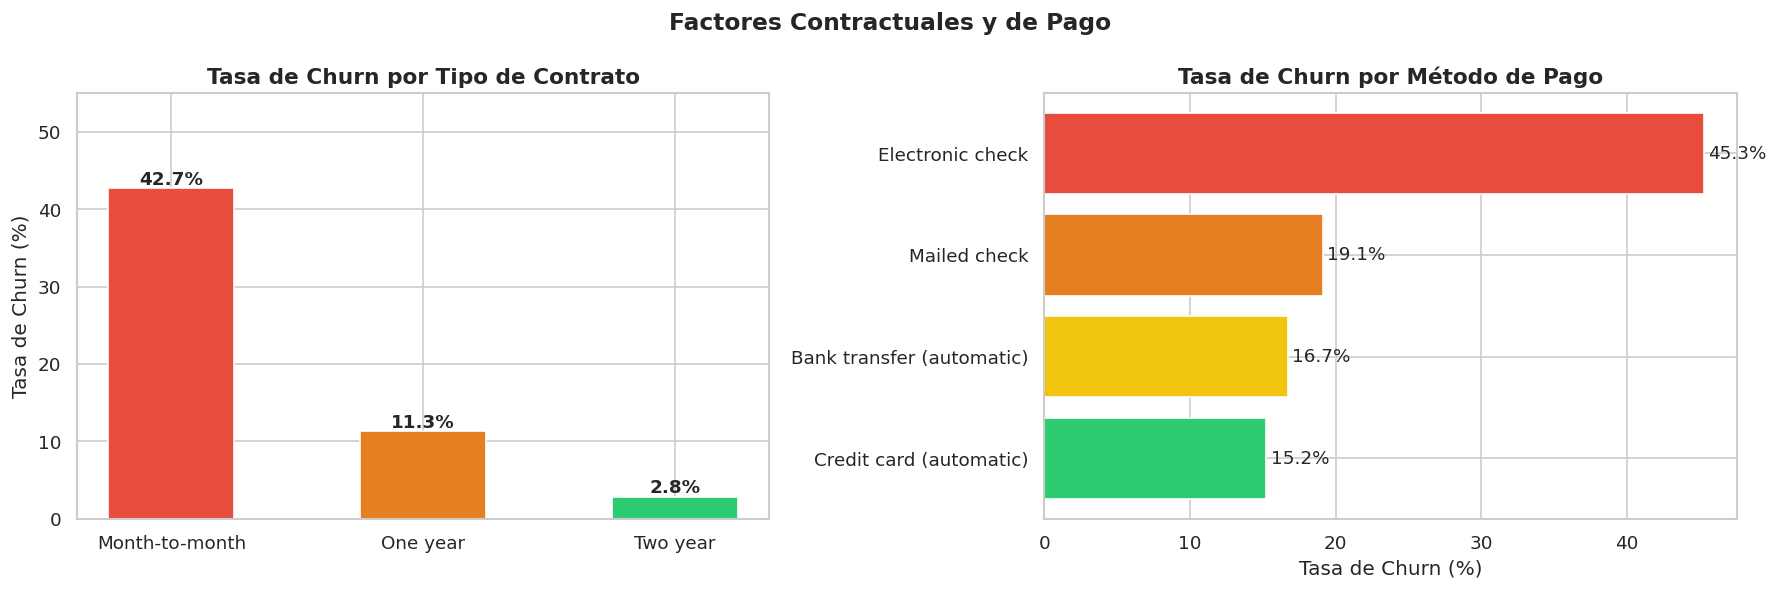

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Contrato
contract_churn = df_clean.groupby('contract')['churn'].mean() * 100
contract_churn = contract_churn.sort_values(ascending=False)
colors_c = ['#e74c3c', '#e67e22', '#2ecc71']
bars = axes[0].bar(contract_churn.index, contract_churn.values,
                   color=colors_c, edgecolor='white', width=0.5)
axes[0].set_title('Tasa de Churn por Tipo de Contrato', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Tasa de Churn (%)')
axes[0].set_ylim(0, 55)
for bar, val in zip(bars, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Método de pago
pay_churn = df_clean.groupby('payment_method')['churn'].mean() * 100
pay_churn = pay_churn.sort_values(ascending=True)
axes[1].barh(pay_churn.index, pay_churn.values,
             color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'],
             edgecolor='white')
axes[1].set_title('Tasa de Churn por Método de Pago', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tasa de Churn (%)')
for i, val in enumerate(pay_churn.values):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=11)

plt.suptitle('Factores Contractuales y de Pago',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.5 Servicios de Internet y Adicionales

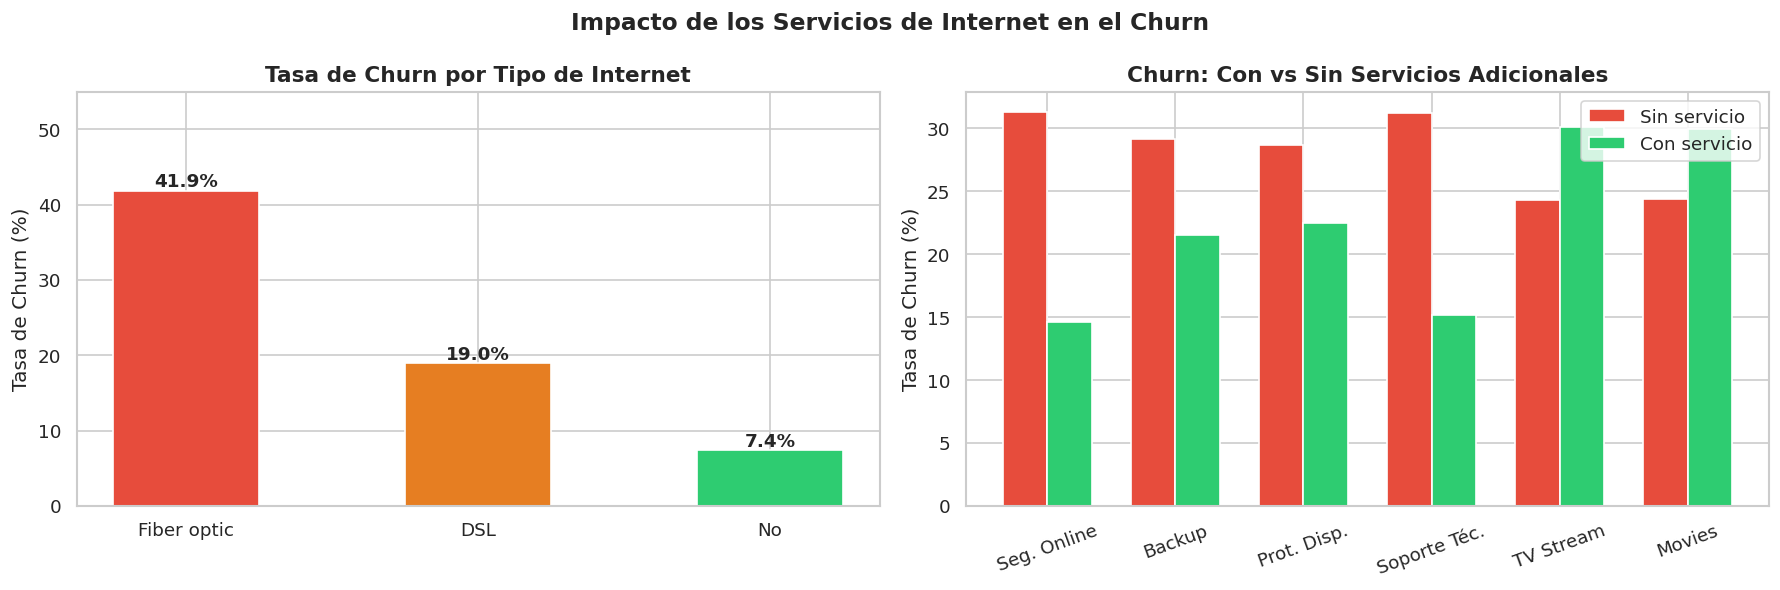

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Internet Service
inet_churn = df_clean.groupby('internet_service')['churn'].mean() * 100
inet_churn = inet_churn.sort_values(ascending=False)
bars = axes[0].bar(inet_churn.index, inet_churn.values,
                   color=['#e74c3c', '#e67e22', '#2ecc71'],
                   edgecolor='white', width=0.5)
axes[0].set_title('Tasa de Churn por Tipo de Internet', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Tasa de Churn (%)')
axes[0].set_ylim(0, 55)
for bar, val in zip(bars, inet_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Servicios adicionales
add_services = ['online_security', 'online_backup', 'device_protection',
                'tech_support', 'streaming_tv', 'streaming_movies']
labels = ['Seg. Online', 'Backup', 'Prot. Disp.', 'Soporte Téc.', 'TV Stream', 'Movies']

churn_no_svc  = [df_clean[df_clean[s] == 0]['churn'].mean() * 100 for s in add_services]
churn_yes_svc = [df_clean[df_clean[s] == 1]['churn'].mean() * 100 for s in add_services]

x = np.arange(len(labels))
w = 0.35
axes[1].bar(x - w/2, churn_no_svc,  w, label='Sin servicio',  color='#e74c3c', edgecolor='white')
axes[1].bar(x + w/2, churn_yes_svc, w, label='Con servicio',  color='#2ecc71', edgecolor='white')
axes[1].set_title('Churn: Con vs Sin Servicios Adicionales', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20)
axes[1].set_ylabel('Tasa de Churn (%)')
axes[1].legend()

plt.suptitle('Impacto de los Servicios de Internet en el Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.6 Análisis de Cargos (Monthly & Total Charges)

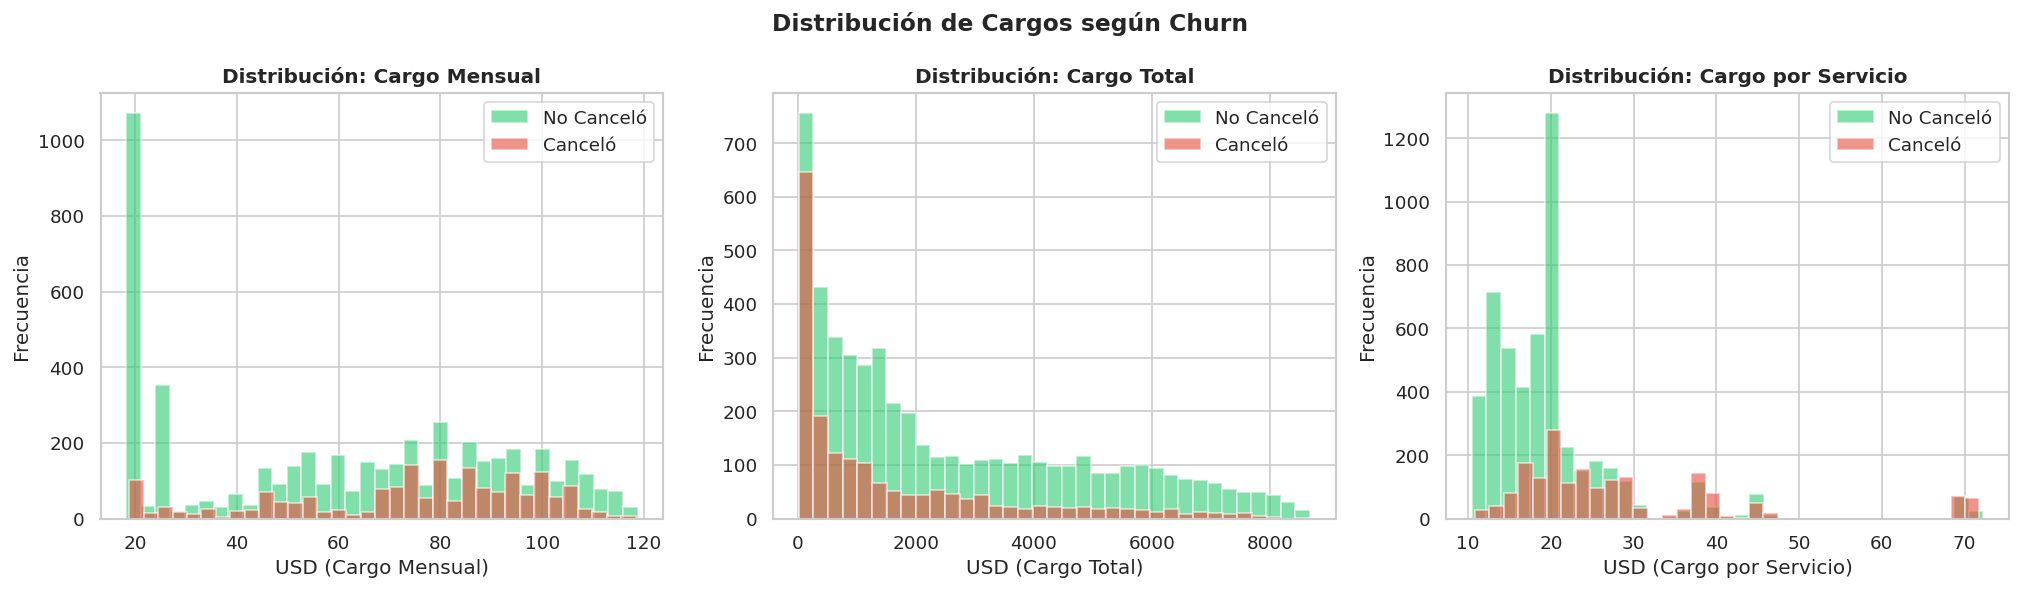

Estadísticas de cargos mensuales por churn:
      monthly_charges                                                   \
                count   mean    std    min    25%    50%   75%     max   
churn                                                                    
0              5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75   
1              1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35   

      total_charges                                                     \
              count     mean      std    min     25%      50%      75%   
churn                                                                    
0            5174.0  2552.88  2327.59  18.80  579.58  1679.52  4262.85   
1            1869.0  1531.80  1890.82  18.85  134.50   703.55  2331.30   

                
           max  
churn           
0      8672.45  
1      8684.80  


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col, title in zip(
    axes,
    ['monthly_charges', 'total_charges', 'charge_per_service'],
    ['Cargo Mensual', 'Cargo Total', 'Cargo por Servicio']
):
    for label, color, name in [(0, '#2ecc71', 'No Canceló'), (1, '#e74c3c', 'Canceló')]:
        vals = df_clean[df_clean['churn'] == label][col]
        ax.hist(vals, bins=35, alpha=0.6, color=color, label=name)
    ax.set_title(f'Distribución: {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'USD ({title})')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.suptitle('Distribución de Cargos según Churn',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Estadísticas de cargos mensuales por churn:')
print(df_clean.groupby('churn')[['monthly_charges', 'total_charges']].describe().round(2))

## 3.7 Número Total de Servicios Contratados

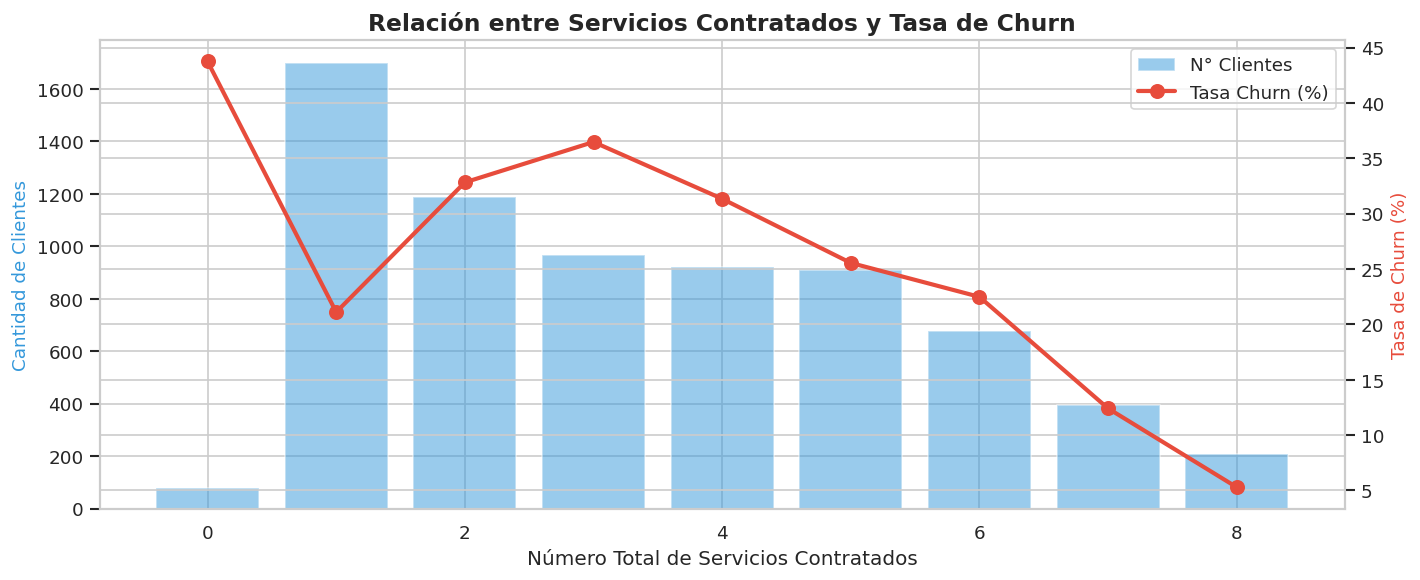

In [17]:
svc_churn = df_clean.groupby('total_services')['churn'].agg(
    tasa=lambda x: x.mean() * 100,
    clientes='count'
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

bars = ax1.bar(svc_churn['total_services'], svc_churn['clientes'],
               color='#3498db', alpha=0.5, label='N° Clientes', edgecolor='white')
line, = ax2.plot(svc_churn['total_services'], svc_churn['tasa'],
                  color='#e74c3c', marker='o', linewidth=2.5,
                  markersize=8, label='Tasa Churn (%)')

ax1.set_xlabel('Número Total de Servicios Contratados', fontsize=12)
ax1.set_ylabel('Cantidad de Clientes', color='#3498db', fontsize=11)
ax2.set_ylabel('Tasa de Churn (%)', color='#e74c3c', fontsize=11)
ax1.set_title('Relación entre Servicios Contratados y Tasa de Churn',
               fontsize=14, fontweight='bold')

lines = [bars, line]
ax1.legend([bars, line], ['N° Clientes', 'Tasa Churn (%)'], loc='upper right')
plt.tight_layout()
plt.show()

## 3.8 Matriz de Correlación con Churn

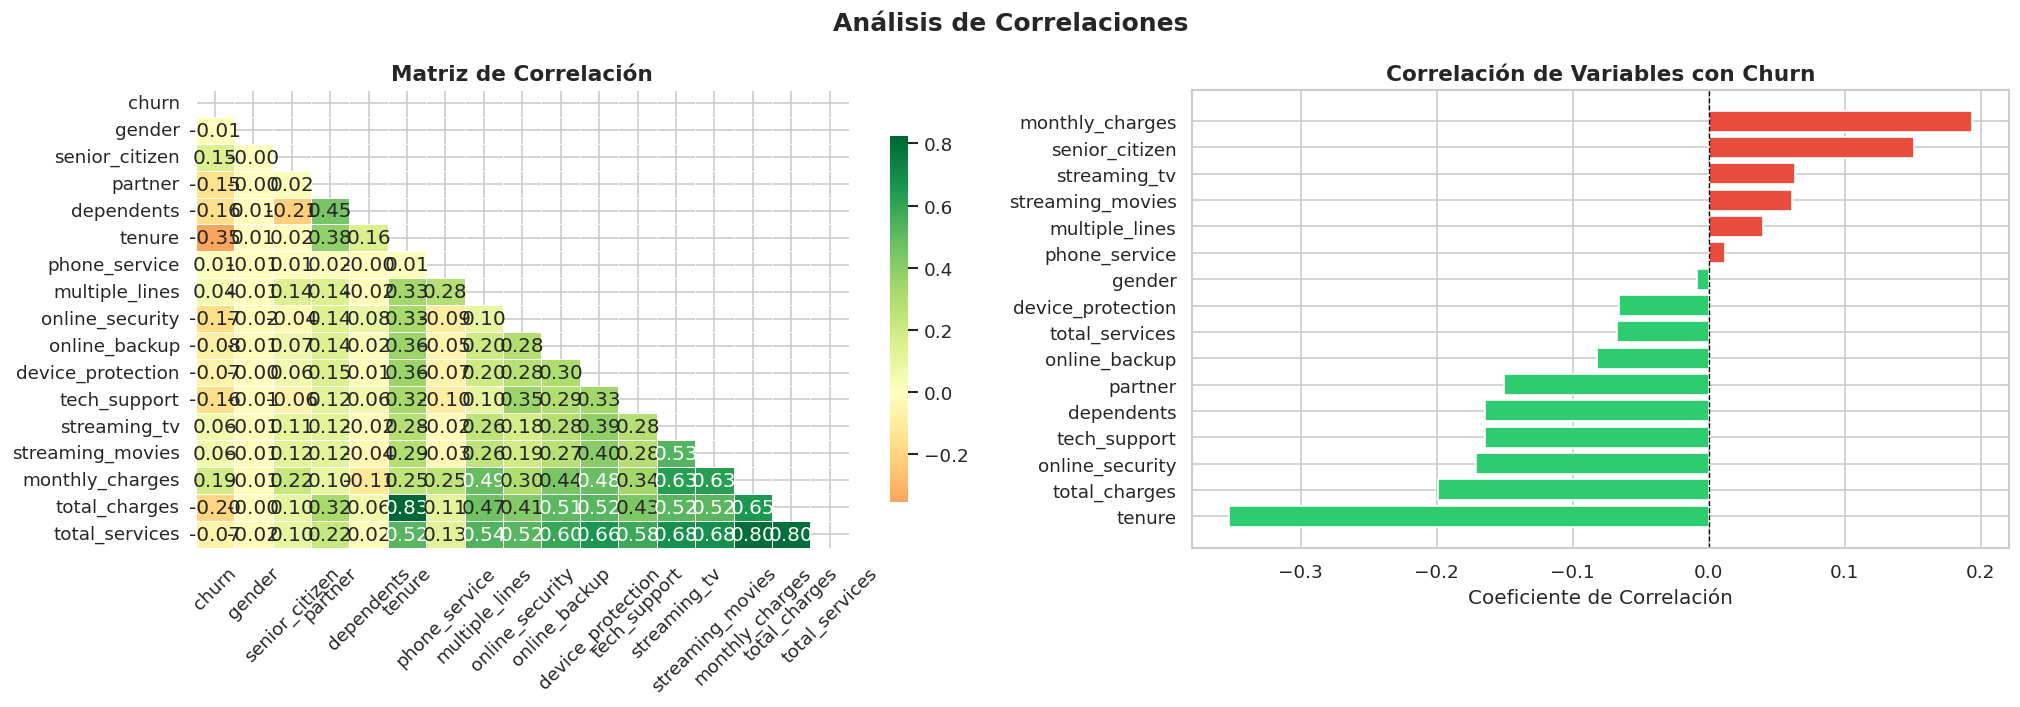

Top 5 variables positivamente correlacionadas con churn:
multiple_lines      0.040
streaming_movies    0.061
streaming_tv        0.063
senior_citizen      0.151
monthly_charges     0.193
Name: churn, dtype: float64

Top 5 variables negativamente correlacionadas con churn:
tenure            -0.352
total_charges     -0.199
online_security   -0.171
tech_support      -0.165
dependents        -0.164
Name: churn, dtype: float64


In [18]:
num_cols = ['churn', 'gender', 'senior_citizen', 'partner', 'dependents',
             'tenure', 'phone_service', 'multiple_lines', 'online_security',
             'online_backup', 'device_protection', 'tech_support',
             'streaming_tv', 'streaming_movies', 'monthly_charges',
             'total_charges', 'total_services']

corr_matrix = df_clean[num_cols].corr()
churn_corr = corr_matrix['churn'].drop('churn').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Matriz de Correlación', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Correlación con churn
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in churn_corr.values]
axes[1].barh(churn_corr.index, churn_corr.values, color=colors, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Correlación de Variables con Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coeficiente de Correlación')

plt.suptitle('Análisis de Correlaciones', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 variables positivamente correlacionadas con churn:')
print(churn_corr.tail(5).round(3))
print('\nTop 5 variables negativamente correlacionadas con churn:')
print(churn_corr.head(5).round(3))

# 4. Informe Final — Conclusiones y Recomendaciones


## Resumen Ejecutivo

Tras aplicar el proceso ETL y el análisis exploratorio sobre **7,043 registros válidos** de clientes de Telecom X, se identificaron los principales factores asociados a la evasión de clientes (churn). La **tasa de churn global es del ~26.5%**, lo que representa una pérdida significativa de ingresos recurrentes.

---

## Hallazgos Clave

### 1️ Tipo de Contrato — Factor Crítico
- Los clientes con **contrato mensual (Month-to-month)** presentan una tasa de churn superior al **42%**, frente al 11% en contratos de 1 año y menos del 3% en contratos de 2 años.
- **Insight:** El compromiso contractual a largo plazo es el predictor más fuerte de retención.

### 2️ Antigüedad (Tenure) — Alta Vulnerabilidad en los Primeros Meses
- Los clientes con **menos de 12 meses** de contrato concentran la mayor parte de los churns. La mediana de tenure de quienes cancelan es de ~10 meses vs ~38 meses de quienes permanecen.
- **Insight:** Los primeros 12 meses son la ventana crítica de retención.

### 3️ Servicio de Internet Fiber Optic — Alto Riesgo
- Clientes con **fibra óptica** tienen tasas de churn cercanas al **42%**, más del doble que los clientes DSL (~19%).
- Puede indicar problemas de calidad de servicio, precio elevado o insatisfacción.

### 4️ Método de Pago — Cheque Electrónico como Señal de Alerta
- Los clientes que pagan con **Electronic Check** tienen la mayor tasa de churn (~45%), mientras que los métodos automáticos (débito bancario, tarjeta de crédito) muestran tasas menores al 18%.
- **Insight:** El pago manual puede correlacionarse con menor compromiso o mayor fricción financiera.

### 5️ Servicios Adicionales — Efecto Protector
- Clientes **sin seguridad online, soporte técnico ni backup** tienen tasas de churn 2-3 veces más altas que quienes sí los tienen.
- A mayor número de servicios contratados, **menor es la tasa de churn**.
- **Insight:** El bundling de servicios genera mayor stickiness.

### 6️ Adultos Mayores y Clientes sin Dependientes
- Los **senior citizens** (~65+ años) presentan una tasa de churn de ~42%.
- Clientes **sin pareja ni dependientes** también muestran mayor propensión a cancelar.

### 7️ Cargos Mensuales Altos
- Los clientes que cancelaron tienen un **cargo mensual promedio mayor** (~$74 vs $61), sugiriendo que la percepción de precio-valor puede ser un factor determinante.

---

## 💡 Recomendaciones Estratégicas

| # | Estrategia | Impacto Esperado |
|---|-----------|------------------|
| 1 | Ofrecer descuentos o beneficios para migrar clientes de contrato mensual a anual | Alto |
| 2 | Implementar programa de onboarding en los primeros 3-6 meses del cliente | Alto |
| 3 | Investigar la calidad/precio del servicio de Fibra Óptica | Alto |
| 4 | Promover la adopción de pagos automáticos (débito/tarjeta) | Medio |
| 5 | Crear bundles de servicios con precios especiales | Medio |
| 6 | Desarrollar atención especializada para adultos mayores | Medio |
| 7 | Alertas tempranas de churn usando los factores identificados en este análisis | Alto |

---

## Próximos Pasos para el Equipo de Data Science

El dataset limpio está listo para la fase de modelado predictivo. Se recomienda utilizar los siguientes modelos como baseline:
- **Logistic Regression** (interpretabilidad)
- **Random Forest / XGBoost** (performance)
- **Variables clave:** `contract`, `tenure`, `internet_service`, `payment_method`, `monthly_charges`, `total_services`, `online_security`

> **Dataset entregado:** `df_clean` — 7,043 registros × 24 columnas, sin nulos, listo para modelado.

In [19]:
# ── Exportar dataset limpio ──
df_clean.to_csv('TelecomX_clean.csv', index=False)
print(f'Dataset limpio exportado: TelecomX_clean.csv')
print(f'   Shape: {df_clean.shape}')
print(f'   Columnas: {list(df_clean.columns)}')

Dataset limpio exportado: TelecomX_clean.csv
   Shape: (7043, 24)
   Columnas: ['customer_id', 'churn', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'total_services', 'tenure_group', 'charge_per_service']
